# Machine Learning for CICY 4-Folds

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import time
import gzip
import json
from IPython.display import Image
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow import keras
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *

import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# set matplot
sns.set()
PREFIX = 'cicy4_'
SUFFIX = '_inception'

# set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# set random seed
RAND = 123
np.random.seed(RAND)
tf.random.set_seed(RAND)

In [2]:
proot = lambda s: os.path.join('.', s)
pdata = lambda s: os.path.join(proot('data'), s)
pimg  = lambda s: os.path.join(proot('img'), s)
ppred = lambda s: os.path.join(proot('pred'), s)
plogs = lambda s: os.path.join(proot('logs'), s)

os.makedirs(proot('data'), exist_ok=True)
os.makedirs(proot('img'), exist_ok=True)
os.makedirs(proot('pred'), exist_ok=True)
os.makedirs(proot('logs'), exist_ok=True)

## Download and Read the Dataset

In [3]:
data = keras.utils.get_file('cicy4_eng.json.gz',
                            'https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz',
                            cache_dir='.',
                            cache_subdir='data'
                           )

14819328/14814325 [==============================] - 4s 0us/step


## Reading the Dataset

In [4]:
df = pd.read_json(pdata('cicy4_eng.json.gz'), orient='index')

In [5]:
# select only non product manifolds
df = df.loc[df['isprod'] == False]

# select only complete entries
df = df.dropna()

## Building the Configuration Matrices (Sparse to Dense)

In [6]:
# get the max shape of the matrix
shape = df['size'].max()

# get the offset and pad the matrix
offset = lambda s: [(0, shape[i] - np.shape(s)[i]) for i in range(len(shape))]
df['matrix'] = df['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))

## Building the Vector Features (Sparse to Dense)

In [7]:
# get the max length
dim_cp_shape  = df['dim_cp'].apply(np.shape).max()
deg_eqs_shape = df['deg_eqs'].apply(np.shape).max()

# get the offset and pad
offset_dim_cp = lambda s: (0, dim_cp_shape[0] - np.shape(s)[0])
df['dim_cp']  = df['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))

offset_deg_eqs = lambda s: (0, deg_eqs_shape[0] - np.shape(s)[0])
df['deg_eqs']   = df['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))

## Plots

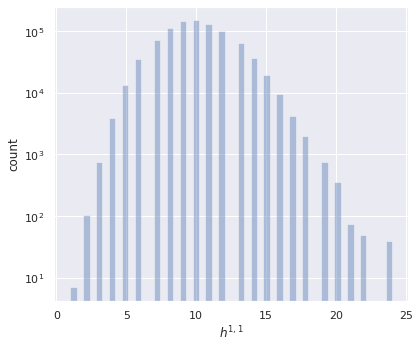

In [8]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h11'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{1,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

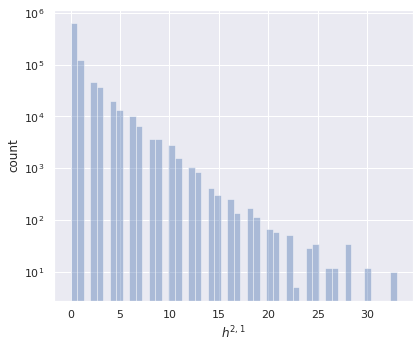

In [9]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h21'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

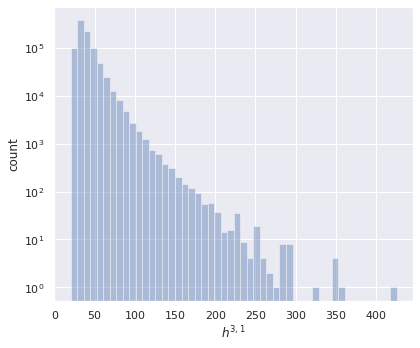

In [10]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h31'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{3,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

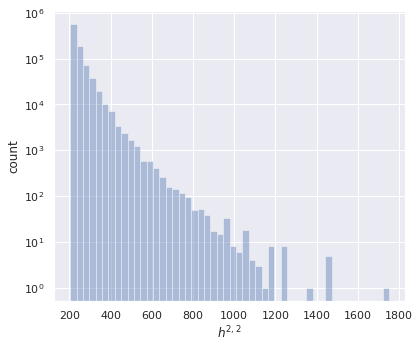

In [11]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h22'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,2}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Correlations

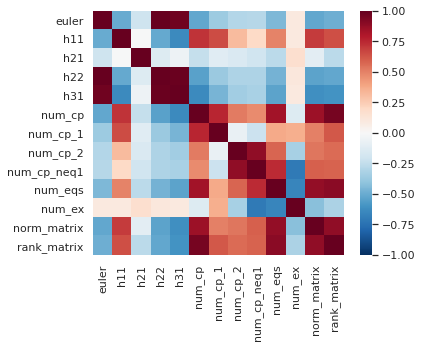

In [12]:
corr = df[['euler',
           'h11',
           'h21',
           'h22',
           'h31',
           'num_cp',
           'num_cp_1',
           'num_cp_2',
           'num_cp_neq1',
           'num_eqs',
           'num_ex',
           'norm_matrix',
           'rank_matrix'
          ]
         ].corr()

_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.heatmap(corr,
            vmin=-1.0,
            vmax=1.0,
            cmap='RdBu_r',
            center=0.0
           )

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'correlations' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Distributions

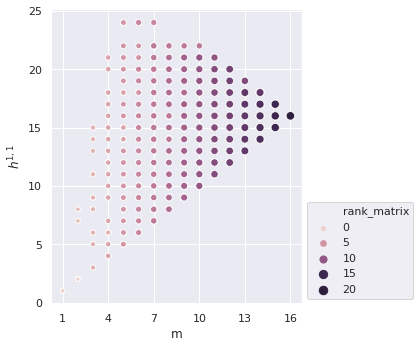

In [13]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h11',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('m')
ax.set_ylabel('$h^{1,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

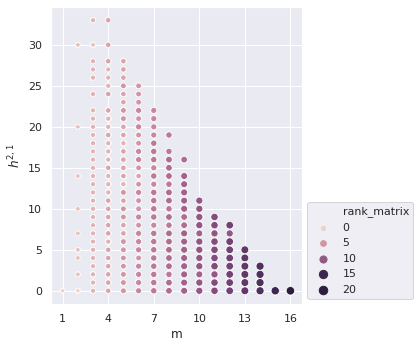

In [14]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h21',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('m')
ax.set_ylabel('$h^{2,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

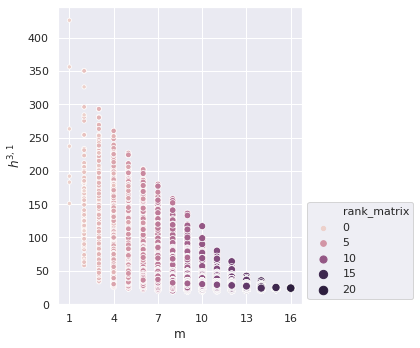

In [15]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h31',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('m')
ax.set_ylabel('$h^{3,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

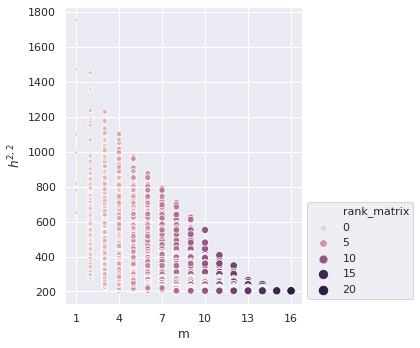

In [16]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h22',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('m')
ax.set_ylabel('$h^{2,2}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

## Train, Validation, Test Splits

In [17]:
batch_size = 64

In [18]:
df_train, df_test = train_test_split(df, test_size=0.02, shuffle=True, random_state=RAND)
df_val, df_test   = train_test_split(df_test, test_size=0.5, shuffle=True, random_state=RAND)

print(f'Training set:   {df_train.shape[0]:d} samples (fraction: {df_train.shape[0] / df.shape[0]:.3f})')
print(f'Validation set: {df_val.shape[0]:d} samples (fraction: {df_val.shape[0] / df.shape[0]:.3f})')
print(f'Test set:       {df_test.shape[0]:d} samples (fraction: {df_test.shape[0] / df.shape[0]:.3f})')

Training set:   887570 samples (fraction: 0.980)
Validation set: 9057 samples (fraction: 0.010)
Test set:       9057 samples (fraction: 0.010)


## Remove Outliers from Train Set

In [19]:
low_quantile  = 0.05
high_quantile = 0.95

quantile = df_train.quantile(q=[low_quantile, high_quantile])
quantile

,euler,favour,h11,h21,h22,h31,isprod,num_cp,num_eqs,num_cp_1,...,min_dim_cp,max_dim_cp,mean_dim_cp,std_dim_cp,median_dim_cp,min_deg_eqs,max_deg_eqs,mean_deg_eqs,std_deg_eqs,median_deg_eqs
0.05,288.0,0.0,6.0,0.0,204.0,27.0,0.0,6.0,6.0,2.0,...,1.0,2.0,1.307692,0.458258,1.0,1.0,1.0,1.000000,0.000000,1.0
0.95,480.0,1.0,14.0,5.0,332.0,64.0,0.0,12.0,14.0,7.0,...,1.0,4.0,2.000000,1.069045,2.0,1.0,2.0,1.285714,0.471405,1.0


In [20]:
df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low_quantile]) & (df_train['h11'] <= quantile['h11'].loc[high_quantile])
                        & (df_train['h21'] >= quantile['h21'].loc[low_quantile]) & (df_train['h21'] <= quantile['h21'].loc[high_quantile])
                        & (df_train['h31'] >= quantile['h31'].loc[low_quantile]) & (df_train['h31'] <= quantile['h31'].loc[high_quantile])
                        & (df_train['h22'] >= quantile['h22'].loc[low_quantile]) & (df_train['h22'] <= quantile['h22'].loc[high_quantile])
                       ]
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 760653 entries, 470930 to 788943
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   euler           760653 non-null  int64  
 1   favour          760653 non-null  bool   
 2   h11             760653 non-null  float64
 3   h21             760653 non-null  float64
 4   h22             760653 non-null  float64
 5   h31             760653 non-null  float64
 6   isprod          760653 non-null  bool   
 7   matrix          760653 non-null  object 
 8   size            760653 non-null  object 
 9   num_cp          760653 non-null  int64  
 10  num_eqs         760653 non-null  int64  
 11  num_cp_1        760653 non-null  int64  
 12  num_cp_2        760653 non-null  int64  
 13  num_cp_neq1     760653 non-null  int64  
 14  num_ex          760653 non-null  int64  
 15  norm_matrix     760653 non-null  float64
 16  rank_matrix     760653 non-null  int64  
 17  dim_c

In [21]:
df_train.to_csv(pdata(PREFIX + 'train_set' + SUFFIX + '.csv'), index=False)
df_val.to_csv(pdata(PREFIX + 'val_set' + SUFFIX + '.csv'), index=False)
df_test.to_csv(pdata(PREFIX + 'test_set' + SUFFIX + '.csv'), index=False)

## Rescale the Matrices

In [22]:
scale = df_train['matrix'].apply(np.max).max()

In [23]:
df_train['matrix'] = df_train['matrix'] / scale
df_val['matrix']   = df_val['matrix'] / scale
df_test['matrix']  = df_test['matrix'] / scale

## Reshape Layers for CNN

In [24]:
reshape = tuple(shape + [1])

In [25]:
df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))
df_val['matrix']   = df_val['matrix'].apply(lambda x: np.reshape(x, reshape))
df_test['matrix']  = df_test['matrix'].apply(lambda x: np.reshape(x, reshape))

## Create Dataset Generators

In [26]:
train_features = {'matrix': list(df_train['matrix'].values),
                  #'scalars': list(df_train[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                  #'dim_cp': list(df_train['dim_cp'].values),
                  #'deg_eqs': list(df_train['deg_eqs'].values)
                 }
val_features = {'matrix': list(df_val['matrix'].values),
                #'scalars': list(df_val[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                #'dim_cp': list(df_val['dim_cp'].values),
                #'deg_eqs': list(df_val['deg_eqs'].values)
               }
test_features = {'matrix': list(df_test['matrix'].values),
                 #'scalars': list(df_test[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                 #'dim_cp': list(df_test['dim_cp'].values),
                 #'deg_eqs': list(df_test['deg_eqs'].values)
                }

In [27]:
#scalars_shape = train_features['scalars'][0].shape

In [28]:
train_labels = {'h11': list(df_train['h11'].values.astype(np.int)),
                'h21': list(df_train['h21'].values.astype(np.int)),
                'h31': list(df_train['h31'].values.astype(np.int)),
                'h22': list(df_train['h22'].values.astype(np.int)),
               }
val_labels = {'h11': list(df_val['h11'].values.astype(np.int)),
              'h21': list(df_val['h21'].values.astype(np.int)),
              'h31': list(df_val['h31'].values.astype(np.int)),
              'h22': list(df_val['h22'].values.astype(np.int)),
             }
test_labels = {'h11': list(df_test['h11'].values.astype(np.int)),
               'h21': list(df_test['h21'].values.astype(np.int)),
               'h31': list(df_test['h31'].values.astype(np.int)),
               'h22': list(df_test['h22'].values.astype(np.int)),
              }

In [29]:
train = tf.data.Dataset.from_tensor_slices((train_features, train_labels)).batch(batch_size).prefetch(2)
val = tf.data.Dataset.from_tensor_slices((val_features, val_labels)).batch(batch_size).prefetch(2)
test = tf.data.Dataset.from_tensor_slices((test_features, test_labels)).batch(batch_size).prefetch(2)

## Model Building

### Inception Network

In [30]:
matrix = nn_inception(input_shape=reshape,
                      name='matrix',
                      learning_rate=1.0e-3,
                      conv_layers=[32, 64, 32],
                      conv_alpha=0.0,
                      conv_class=None,
                      conv_single=False,
                      conv_red=0,
                      feat_map=0,
                      recurrent=False,
                      fc_layers=[10, 10],
                      fc_alpha=0.0,
                      dropout=0.2,
                      full_dropout=0.0,
                      batchnorm=0.99,
                      last_relu=True,
                      loss_weights=[0.15, 0.15, 0.30, 0.40],
                      l1_reg=1.0e-4,
                      l2_reg=1.0e-4,
                      output_layers=True
                      #output_layers=False
                     )

matrix.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 32)   544         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 32)   672         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 32)   0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

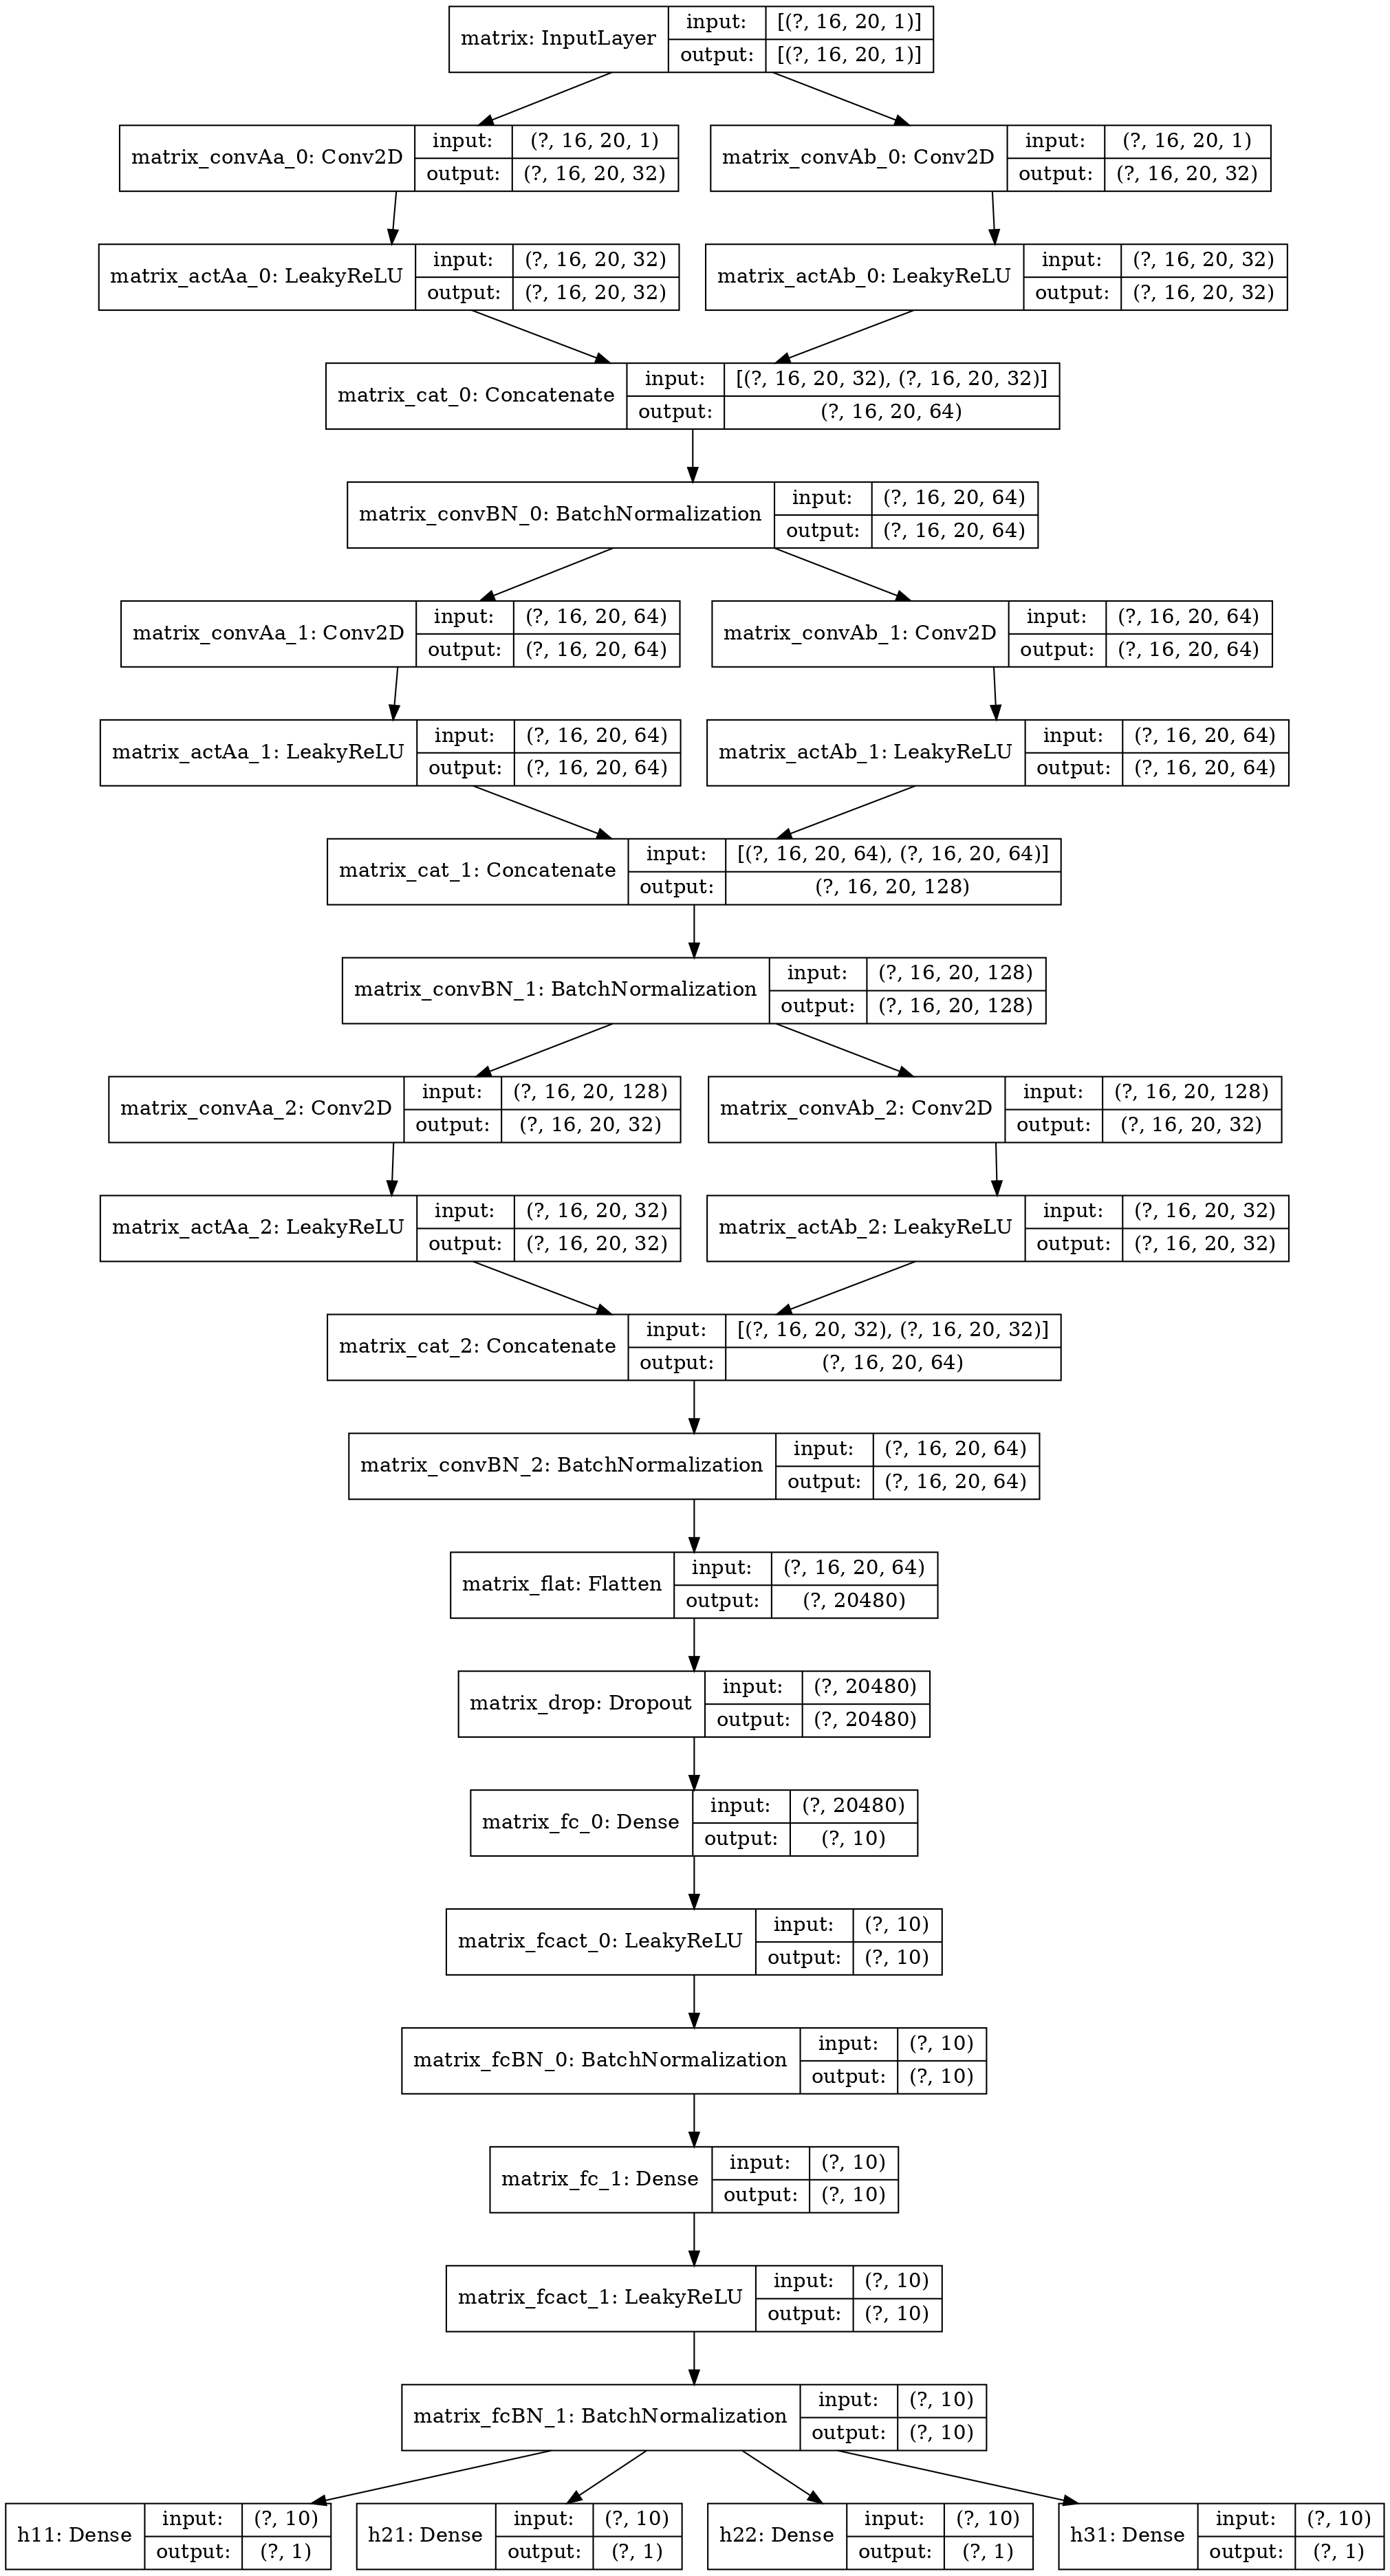

In [31]:
matrix_graph = keras.utils.model_to_dot(matrix, show_shapes=True, dpi=150)
matrix_graph.write_pdf(pimg(PREFIX + 'matrix_graph' + SUFFIX + '.pdf'))
Image(matrix_graph.create_png(), width=480)

### Dense Network

In [32]:
#scalars = nn_dense(input_shape=scalars_shape,
#                   name='scalars',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[10, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#scalars.summary()

In [33]:
#scalars_graph = keras.utils.model_to_dot(scalars, show_shapes=True, dpi=150)
#scalars_graph.write_pdf(pimg(PREFIX + 'scalars_graph' + SUFFIX + '.pdf'))
#Image(scalars_graph.create_png(), width=480)

In [34]:
#dim_cp = nn_dense(input_shape=dim_cp_shape,
#                  name='dim_cp',
#                  learning_rate=1.0e-3,
#                  recurrent=False,
#                  fc_layers=[20, 10, 5],
#                  fc_alpha=0.0,
#                  dropout=0.1,
#                  batchnorm=0.99,
#                  last_relu=True,
#                  loss_weights=[0.25, 0.25, 0.25, 0.25],
#                  l1_reg=1.0e-5,
#                  l2_reg=1.0e-5,
#                  output_layers=True
#                  #output_layers=False
#                 )
#
#dim_cp.summary()

In [35]:
#dim_cp_graph = keras.utils.model_to_dot(dim_cp, show_shapes=True, dpi=150)
#dim_cp_graph.write_pdf(pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.pdf'))
#Image(dim_cp_graph.create_png(), width=480)

In [36]:
#deg_eqs = nn_dense(input_shape=deg_eqs_shape,
#                   name='deg_eqs',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[20, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#deg_eqs.summary()

In [37]:
#deg_eqs_graph = keras.utils.model_to_dot(deg_eqs, show_shapes=True, dpi=150)
#deg_eqs_graph.write_pdf(pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.pdf'))
#Image(deg_eqs_graph.create_png(), width=480)

### Full Model

In [38]:
#full_model = nn_full([matrix, scalars, dim_cp, deg_eqs],
#                     name='full_model',
#                     learning_rate=1.0e-3,
#                     last_relu=True,
#                     fc_layers=[20],
#                     fc_alpha=0.0,
#                     batchnorm=0.99,
#                     dropout=0.0,
#                     loss_weights=[0.25, 0.25, 0.25, 0.25],
#                     l1_reg=0.0,
#                     l2_reg=0.0
#                    )
#full_model.summary()

In [39]:
#full_model_graph = keras.utils.model_to_dot(full_model, show_shapes=True, dpi=150)
#full_model_graph.write_pdf(pimg(PREFIX + 'full_model_graph' + SUFFIX + '.pdf'))
#Image(full_model_graph.create_png(), width=480)

## Training the Model

In [40]:
epochs   = 60
interval = int(epochs / 10) if epochs > 10 else 1

In [41]:
full_model = matrix
full_model_hst = full_model.fit(train,
                                batch_size=batch_size,
                                epochs=epochs,
                                verbose=0,
                                callbacks=[keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'inception' + SUFFIX + '.h5'),
                                                                           monitor='val_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h11_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h21_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h31_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h22_loss',
                                                                           save_best_only=True
                                                                          ),
                                           #keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True),
                                           keras.callbacks.ReduceLROnPlateau(factor=0.3,
                                                                             patience=75,
                                                                             min_lr=1.0e-6
                                                                            ),
                                           keras.callbacks.TensorBoard(log_dir=proot('logs'),
                                                                       histogram_freq=interval,
                                                                       write_graph=True,
                                                                       write_images=True,
                                                                       update_freq='epoch',
                                                                       profile_batch=2,
                                                                       embeddings_freq=interval,
                                                                       embeddings_metadata=None
                                                                      ),
                                           PrintCheckpoint(interval)
                                          ],
                                validation_data=val
                               )

Training has started. Callouts will be printed every 6 epochs.

Training epoch 6. Started on 14/09/2020 at 16:58:33.

    Epoch training time: 139.568 seconds
    loss = 13.537
    h11_loss = 0.322
    h21_loss = 0.798
    h22_loss = 33.904
    h31_loss = 2.508
    h11_mean_squared_error = 0.322
    h11_mean_absolute_error = 0.428
    h21_mean_squared_error = 0.798
    h21_mean_absolute_error = 0.509
    h22_mean_squared_error = 33.904
    h22_mean_absolute_error = 4.369
    h31_mean_squared_error = 2.508
    h31_mean_absolute_error = 1.205
    val_loss = 279.012
    val_h11_loss = 0.783
    val_h21_loss = 2.060
    val_h22_loss = 855.828
    val_h31_loss = 49.170
    val_h11_mean_squared_error = 0.783
    val_h11_mean_absolute_error = 0.508
    val_h21_mean_squared_error = 2.060
    val_h21_mean_absolute_error = 0.671
    val_h22_mean_squared_error = 855.828
    val_h22_mean_absolute_error = 7.585
    val_h31_mean_squared_error = 49.170
    val_h31_mean_absolute_error = 1.862
    lr =

KeyboardInterrupt: 

In [ ]:
full_model     = keras.models.load_model(pdata(PREFIX + 'inception' + SUFFIX + '.h5'))
full_h11_model = keras.models.load_model(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'))
full_h21_model = keras.models.load_model(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'))
full_h31_model = keras.models.load_model(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'))
full_h22_model = keras.models.load_model(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'))

In [ ]:
history = pd.DataFrame(full_model_hst.history)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['loss', 'val_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['val_h11_loss', 'val_h21_loss', 'val_h31_loss', 'val_h22_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('validation loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['$h^{1,1}$', '$h^{2,1}$', '$h^{3,1}$', '$h^{2,2}$'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'val_loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['lr']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('learning rate')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'learning_rate' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Full Model

In [ ]:
_ = full_model.evaluate(test, verbose=1)

In [ ]:
train_predictions = full_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '.csv'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{1,1}$ Model

In [ ]:
_ = full_h11_model.evaluate(test, verbose=1)

In [ ]:
train_predictions = full_h11_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h11_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h11_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h11_model.csv'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,1}$ Model

In [ ]:
_ = full_h21_model.evaluate(test, verbose=1)

In [ ]:
train_predictions = full_h21_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h21_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h21_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h21_model.csv'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{3,1}$ Model

In [ ]:
_ = full_h31_model.evaluate(test, verbose=1)

In [ ]:
train_predictions = full_h31_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h31_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h31_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h31_model.csv'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,2}$ Model

In [ ]:
_ = full_h22_model.evaluate(test, verbose=1)

In [ ]:
train_predictions = full_h22_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h22_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h22_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h22_model.csv'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)